# Quantifying the difference between GPCA and TPCA

In this notebook, we compare GPCA and TPCA on $K=40$ toy datasets of symmetric positive definite (SPD) matrices. 

The $k$-th dataset is composed of $n=20$ covariance matrices $\Sigma^k_1,...,\Sigma^k_n$ that all have the same eigenvalues $a_k^2,b_k^2$ but different orientations. Each $(a_k,b_k)$ is chosen so that the ratio $b_k/a_k$ increases from $0.01$ to $0.99$. Specifically, we choose $\Sigma^k_i=P_{\theta_i}\text{diag}(a_k^2,b_k^2)P_{\theta_i}^\top$, where where $P_{\theta}$ is the rotation matrix of angle $\theta$ and angles $\theta_i$ are equally spaced between $1/n\pi$ and $\pi-1/n\pi$. Each dataset is thus composed of $n=20$ covariance matrices displayed on an open circle inside the cone of SPD matrices, with increasing radius. 

On each dataset, we then perform GPCA and TPCA at the Bures-Wasserstein barycenter $\bar \Sigma^k$, and measure the cost improvement
$$\frac{\rm cost(\Sigma_{TPCA}) - cost(\Sigma_{GPCA})}{\rm cost(\Sigma_{TPCA})} \quad \text{where}\quad {\rm cost} = \sum_{i=1}^n \inf_{t_i}BW_2^2(\Sigma_i,\Sigma(t_i))$$
is the sum-of-squared residuals of the Bures-Wasserstein-projections of the data $\Sigma_1,...,\Sigma_n$ on the component $\Sigma(t)$, and $\rm\Sigma_{TPCA}$ and $\rm\Sigma_{GPCA}$ denote the first components found by TPCA and GPCA respectively. This procedure is repeated 10 times for each dataset. We then plot the average cost improvement as a function of $(a-b)^2/(a+b)^2$. This plot shows that the difference between GPCA and TPCA increases as this ratio increases, i.e., as the radius of the circle increases and the SPD matrices get closer to the border of the cone. This is coherent with the result of Proposition 4 in [1].

The figure shown in this notebook correspond to Figure 4 in [1].

[1] N. Vesseron, E. Cazelles, A. Le Brigant and T. Klein. On the Wasserstein Geodesic Principal Components Analysis of probability measures, *International Conference on Learning Representations (ICLR)*, 2026

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm

from pca.bures_wasserstein_geodesic_pca import *
from pca.bures_wasserstein_tangent_pca import *

import warnings
warnings.filterwarnings('ignore')

INFO: Using numpy backend


In [3]:
np.random.seed(123)

In [4]:
def pca_on_spd_matrices_with_same_eigenvalues(a, b, n_points=20):
    eig = np.array([a ** 2, b ** 2])
    angles = np.linspace(np.pi / 20, np.pi - np.pi / 20, n_points)
    rotations = make_rotation_2d(angles)
    spd_points = np.stack([rot @ np.diag(eig) @ rot.T for rot in rotations])

    res_tpca = BuresWassersteinTPCA().fit(spd_points)
    res_gpca = BuresWassersteinGPCA(dim=2).fit(spd_points)
    cost_ratio = (res_tpca.costs[0] - res_gpca.costs[0]) / res_tpca.costs[0]
    return spd_points, cost_ratio, res_gpca.costs, res_tpca.costs

#### Generate different eigenvalue ratios

In [5]:
n_dataset = 40
eps = 0.01
ab_quotient = np.linspace(eps, 1-eps, n_dataset)
ab_ratio = (1 + ab_quotient) / (1 - ab_quotient)

#### Generate datasets of SPD matrices for each eigenvalue ratio and perform GPCA

In [6]:
n_points = 20
n_repeat = 10

spd_points = np.zeros((n_dataset, n_points, 2, 2))
gpca_costs = np.zeros((n_dataset, n_repeat, 3))
tpca_costs = np.zeros((n_dataset, n_repeat, 3))
cost_ratio = np.zeros((n_dataset, n_repeat))
for i in range(n_dataset):
    print(i, end=" ")
    for j in range(n_repeat):
        a = np.random.uniform(low=1., high=5.)
        b = ab_ratio[i] * a
        spd_points[i], cost_ratio[i, j], gpca_costs[i, j], tpca_costs[i, j] = pca_on_spd_matrices_with_same_eigenvalues(a, b, n_points)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 

#### Visualize the difference between GPCA and TPCA as a function of the eigenvalue ratio

The cost improvement (in terms of minimization) of GPCA with respect to TPCA is shown, on average for 10 runs, per value of the ratio. The blue strip indicates standard deviation.

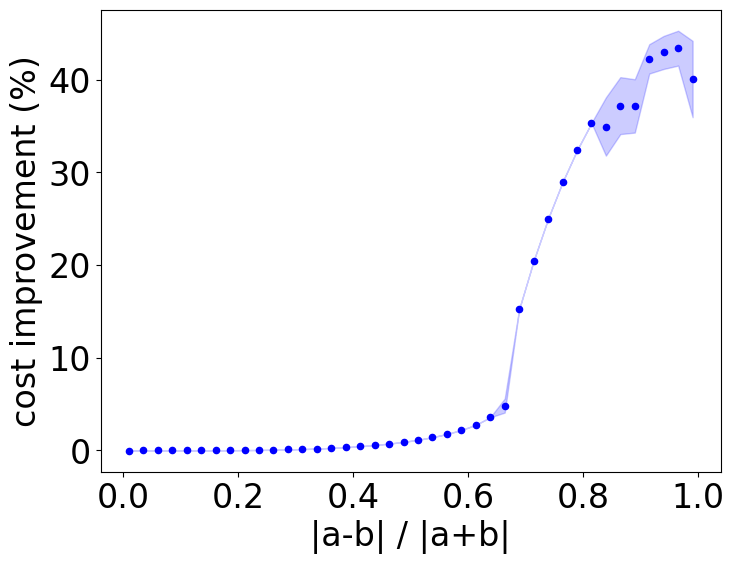

In [13]:
font = {'size': 24}
matplotlib.rc('font', **font)

X = cost_ratio.T * 100
mean = np.mean(X, 0)
std = np.std(X, 0)
plt.figure(figsize=(8, 6))
plt.scatter(ab_quotient, mean, s = 20, color='b')
plt.fill_between(ab_quotient, mean - 1.96 * std / np.sqrt(10), mean + 1.96 * std / np.sqrt(10), color='b', alpha=0.2)
plt.xlabel('|a-b| / |a+b|')
plt.ylabel('cost improvement (%)')
plt.show()